# Notebook 02 – Hypothesis Testing
**DSA 210 – Social Media Use & Mental Health**

We test four hypotheses about the relationship between social media usage and mental health
using the **Social Media & Mental Health Survey** (`smmh.csv`, 481 survey responses).

| # | Hypothesis | Test |
|---|-----------|------|
| H1 | Heavy users (>3h/day) have significantly higher overall mental health risk scores | Two-sample t-test + Mann-Whitney U |
| H2 | Daily usage hours positively correlates with depression sub-score | Pearson + Spearman correlation |
| H3 | Daily usage hours positively correlates with anxiety sub-score | Pearson + Spearman correlation |
| H4 | Students spend more time on social media than non-students | Two-sample t-test |

**Significance level:** α = 0.05

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

sns.set_theme(style="whitegrid", font_scale=1.1)
os.makedirs("../figures", exist_ok=True)

# ── Column rename map (mirrors data_cleaner.py) ──────────────────────────────
COL_RENAME = {
    "1. What is your age?": "age",
    "2. Gender": "gender",
    "3. Relationship Status": "relationship_status",
    "4. Occupation Status": "occupation",
    "5. What type of organizations are you affiliated with?": "org_type",
    "6. Do you use social media?": "uses_social_media",
    "7. What social media platforms do you commonly use?": "platforms",
    "8. What is the average time you spend on social media every day?": "daily_usage",
    "9. How often do you find yourself using Social media without a specific purpose?": "purposeless_use",
    "10. How often do you get distracted by Social media when you are busy doing something?": "distraction_busy",
    "11. Do you feel restless if you haven't used Social media in a while?": "restlessness",
    "12. On a scale of 1 to 5, how easily distracted are you?": "easily_distracted",
    "13. On a scale of 1 to 5, how much are you bothered by worries?": "bothered_by_worries",
    "14. Do you find it difficult to concentrate on things?": "difficulty_concentrating",
    "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?": "compare_to_others",
    "16. Following the previous question, how do you feel about these comparisons, generally speaking?": "feeling_about_comparisons",
    "17. How often do you look to seek validation from features of social media?": "seek_validation",
    "18. How often do you feel depressed or down?": "feel_depressed",
    "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?": "interest_fluctuation",
    "20. On a scale of 1 to 5, how often do you face issues regarding sleep?": "sleep_issues",
}

USAGE_MAP = {
    "Less than an Hour":     0.5,
    "Between 1 and 2 hours": 1.5,
    "Between 2 and 3 hours": 2.5,
    "Between 3 and 4 hours": 3.5,
    "Between 4 and 5 hours": 4.5,
    "More than 5 hours":     6.0,
}

MENTAL_HEALTH_COLS = [
    "purposeless_use", "distraction_busy", "restlessness",
    "easily_distracted", "bothered_by_worries", "difficulty_concentrating",
    "compare_to_others", "feeling_about_comparisons", "seek_validation",
    "feel_depressed", "interest_fluctuation", "sleep_issues",
]

# Load & clean
raw = pd.read_csv("../data/raw/smmh.csv")
df = raw.rename(columns={c: COL_RENAME[c] for c in raw.columns if c in COL_RENAME})
df = df[df["uses_social_media"].str.strip().str.lower() == "yes"].copy()
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df = df[(df["age"] >= 13) & (df["age"] <= 75)].copy()
df["daily_usage_hours"] = df["daily_usage"].map(USAGE_MAP)
for col in MENTAL_HEALTH_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=MENTAL_HEALTH_COLS + ["daily_usage_hours"]).reset_index(drop=True)

# Derived features
df["mh_score"]         = df[MENTAL_HEALTH_COLS].mean(axis=1).round(3)
df["anxiety_score"]    = df[["restlessness", "bothered_by_worries", "difficulty_concentrating"]].mean(axis=1).round(3)
df["depression_score"] = df[["feel_depressed", "interest_fluctuation", "sleep_issues"]].mean(axis=1).round(3)
df["is_student"]       = df["occupation"].str.lower().str.contains("student", na=False).astype(int)
df["heavy_user"]       = (df["daily_usage_hours"] > 3).astype(int)   # >3h/day = heavy user

print(f"Loaded {len(df)} social media users  |  {df['heavy_user'].sum()} heavy users ({df['heavy_user'].mean()*100:.1f}%)")
df[["age", "daily_usage_hours", "mh_score", "anxiety_score", "depression_score"]].describe().round(2)

Loaded 477 social media users  |  276 heavy users (57.9%)


,age,daily_usage_hours,mh_score,anxiety_score,depression_score
count,477.00,477.00,477.00,477.00,477.00
mean,25.96,3.55,3.12,3.14,3.22
std,9.43,1.75,0.77,1.03,1.03
min,13.00,0.50,1.00,1.00,1.00
25%,21.00,2.50,2.67,2.33,2.67
50%,22.00,3.50,3.17,3.33,3.33
75%,26.00,4.50,3.67,4.00,4.00
max,69.00,6.00,5.00,5.00,5.00


---
## H1: Heavy social media users have higher mental health risk scores

**Groups:** Heavy users (>3 h/day) vs Light users (≤3 h/day)  
**Null hypothesis (H₀):** The two groups have equal mean mental health risk scores  
**Test:** Two-sample independent t-test (+ Mann-Whitney U as non-parametric check)  
**Significance level:** α = 0.05

In [2]:
heavy = df.loc[df["heavy_user"] == 1, "mh_score"].dropna()
light = df.loc[df["heavy_user"] == 0, "mh_score"].dropna()

print(f"Heavy users (n={len(heavy)}): mean={heavy.mean():.3f}, std={heavy.std():.3f}")
print(f"Light users (n={len(light)}): mean={light.mean():.3f}, std={light.std():.3f}")

# Normality check (Shapiro-Wilk; use only if n ≤ 5000)
_, p_norm_heavy = stats.shapiro(heavy)
_, p_norm_light = stats.shapiro(light)
print(f"\nShapiro-Wilk p-values: heavy={p_norm_heavy:.3f}, light={p_norm_light:.3f}")

# Levene's test for equal variances
_, p_levene = stats.levene(heavy, light)
equal_var = p_levene > 0.05
print(f"Levene p={p_levene:.3f}  →  equal variances assumed: {equal_var}")

# Independent t-test (Welch if variances unequal)
t_stat, p_ttest = stats.ttest_ind(heavy, light, equal_var=equal_var)
print(f"\nWelch t-test: t={t_stat:.3f}, p={p_ttest:.4f}")

# Mann-Whitney U (non-parametric)
u_stat, p_mw = stats.mannwhitneyu(heavy, light, alternative="greater")
print(f"Mann-Whitney U: U={u_stat:.1f}, p={p_mw:.4f}")

# Effect size (Cohen's d)
pooled_std = np.sqrt((heavy.std()**2 + light.std()**2) / 2)
cohens_d_h1 = (heavy.mean() - light.mean()) / pooled_std
print(f"Cohen's d = {cohens_d_h1:.3f}")

result_h1 = "REJECTED" if p_ttest < 0.05 else "NOT REJECTED"
print(f"\nH1 null hypothesis: {result_h1} (α=0.05)")

Heavy users (n=276): mean=3.362, std=0.678
Light users (n=201): mean=2.779, std=0.758

Shapiro-Wilk p-values: heavy=0.008, light=0.423
Levene p=0.147  →  equal variances assumed: True

Welch t-test: t=8.830, p=0.0000
Mann-Whitney U: U=40056.5, p=0.0000
Cohen's d = 0.812

H1 null hypothesis: REJECTED (α=0.05)


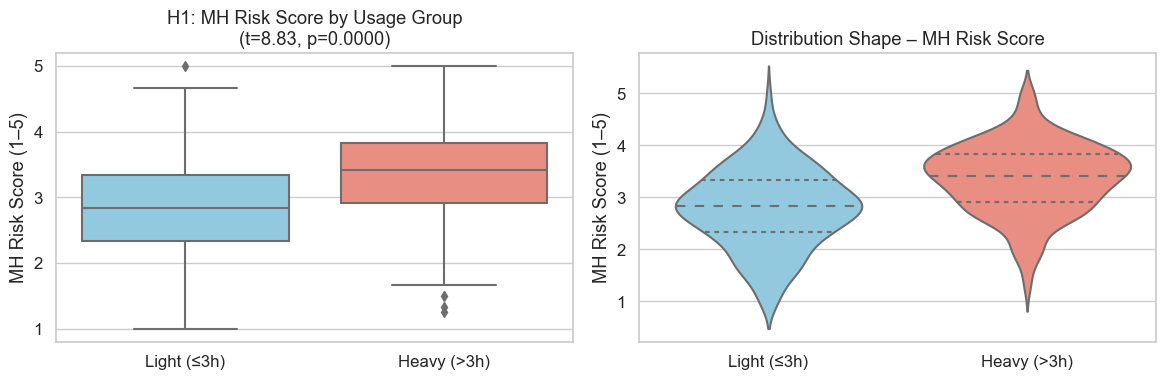

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot
df["Usage Group"] = df["heavy_user"].map({1: "Heavy (>3h)", 0: "Light (≤3h)"})
sns.boxplot(data=df, x="Usage Group", y="mh_score",
            palette={"Heavy (>3h)": "salmon", "Light (≤3h)": "skyblue"}, ax=axes[0])
axes[0].set_title(f"H1: MH Risk Score by Usage Group\n(t={t_stat:.2f}, p={p_ttest:.4f})")
axes[0].set_ylabel("MH Risk Score (1–5)")
axes[0].set_xlabel("")

# Violin plot
sns.violinplot(data=df, x="Usage Group", y="mh_score",
               palette={"Heavy (>3h)": "salmon", "Light (≤3h)": "skyblue"},
               inner="quartile", ax=axes[1])
axes[1].set_title("Distribution Shape – MH Risk Score")
axes[1].set_ylabel("MH Risk Score (1–5)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig("../figures/h1_heavy_vs_light.png", dpi=150, bbox_inches="tight")
plt.show()

---
## H2: Daily social media usage positively correlates with depression sub-score

**Variables:** `daily_usage_hours` (continuous) vs `depression_score` (mean of depressed feeling, interest fluctuation, sleep issues)  
**Null hypothesis (H₀):** ρ = 0 (no correlation)  
**Tests:** Pearson r + Spearman ρ  
**Significance level:** α = 0.05

In [4]:
valid_h2 = df[["daily_usage_hours", "depression_score"]].dropna()
print(f"Valid rows: {len(valid_h2)}")

# Pearson
r_h2, p_h2 = stats.pearsonr(valid_h2["daily_usage_hours"], valid_h2["depression_score"])
print(f"Pearson  r = {r_h2:.3f},  p = {p_h2:.4f}")

# Spearman
rho_h2, p_rho_h2 = stats.spearmanr(valid_h2["daily_usage_hours"], valid_h2["depression_score"])
print(f"Spearman ρ = {rho_h2:.3f},  p = {p_rho_h2:.4f}")

result_h2 = "SUPPORTED" if p_h2 < 0.05 and r_h2 > 0 else "NOT SUPPORTED"
print(f"\nH2: Positive correlation hypothesis {result_h2} (α=0.05)")

Valid rows: 477
Pearson  r = 0.328,  p = 0.0000
Spearman ρ = 0.318,  p = 0.0000

H2: Positive correlation hypothesis SUPPORTED (α=0.05)


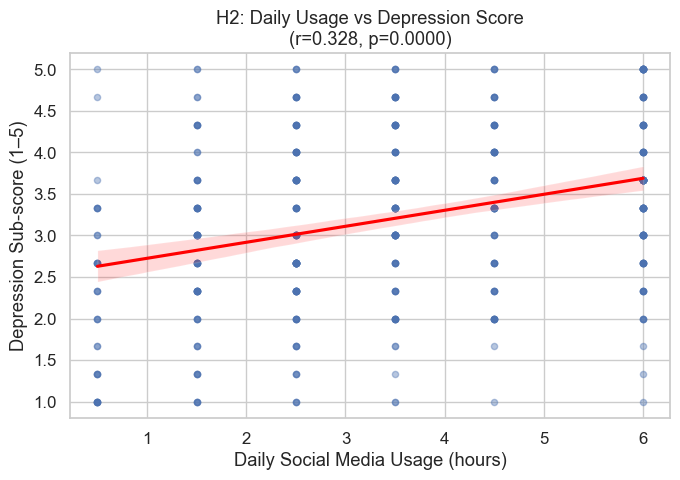

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=valid_h2, x="daily_usage_hours", y="depression_score", ax=ax,
            scatter_kws={"alpha": 0.4, "s": 20}, line_kws={"color": "red"})
ax.set_title(f"H2: Daily Usage vs Depression Score\n(r={r_h2:.3f}, p={p_h2:.4f})")
ax.set_xlabel("Daily Social Media Usage (hours)")
ax.set_ylabel("Depression Sub-score (1–5)")
plt.tight_layout()
plt.savefig("../figures/h2_usage_depression.png", dpi=150, bbox_inches="tight")
plt.show()

---
## H3: Daily social media usage positively correlates with anxiety sub-score

**Variables:** `daily_usage_hours` vs `anxiety_score` (mean of restlessness, bothered by worries, difficulty concentrating)  
**Null hypothesis (H₀):** ρ = 0 (no correlation)  
**Tests:** Pearson r + Spearman ρ  
**Significance level:** α = 0.05

In [6]:
valid_h3 = df[["daily_usage_hours", "anxiety_score"]].dropna()
print(f"Valid rows: {len(valid_h3)}")

# Pearson
r_h3, p_h3 = stats.pearsonr(valid_h3["daily_usage_hours"], valid_h3["anxiety_score"])
print(f"Pearson  r = {r_h3:.3f},  p = {p_h3:.4f}")

# Spearman
rho_h3, p_rho_h3 = stats.spearmanr(valid_h3["daily_usage_hours"], valid_h3["anxiety_score"])
print(f"Spearman ρ = {rho_h3:.3f},  p = {p_rho_h3:.4f}")

result_h3 = "SUPPORTED" if p_h3 < 0.05 and r_h3 > 0 else "NOT SUPPORTED"
print(f"\nH3: Positive correlation hypothesis {result_h3} (α=0.05)")

Valid rows: 477
Pearson  r = 0.422,  p = 0.0000
Spearman ρ = 0.411,  p = 0.0000

H3: Positive correlation hypothesis SUPPORTED (α=0.05)


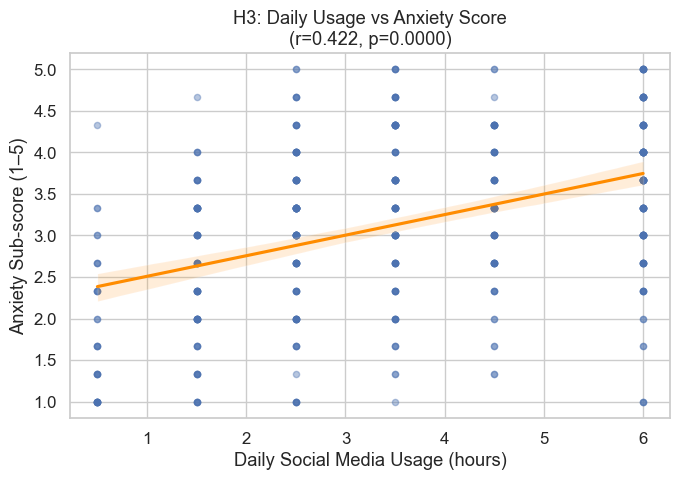

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=valid_h3, x="daily_usage_hours", y="anxiety_score", ax=ax,
            scatter_kws={"alpha": 0.4, "s": 20}, line_kws={"color": "darkorange"})
ax.set_title(f"H3: Daily Usage vs Anxiety Score\n(r={r_h3:.3f}, p={p_h3:.4f})")
ax.set_xlabel("Daily Social Media Usage (hours)")
ax.set_ylabel("Anxiety Sub-score (1–5)")
plt.tight_layout()
plt.savefig("../figures/h3_usage_anxiety.png", dpi=150, bbox_inches="tight")
plt.show()

---
## H4: Students spend more time on social media than non-students

**Groups:** Students (`occupation` contains "Student") vs Non-students  
**Null hypothesis (H₀):** Mean daily usage hours are equal in both groups  
**Tests:** Two-sample t-test + Mann-Whitney U  
**Significance level:** α = 0.05


In [8]:
students     = df.loc[df["is_student"] == 1, "daily_usage_hours"].dropna()
non_students = df.loc[df["is_student"] == 0, "daily_usage_hours"].dropna()

print(f"Students     (n={len(students)}):     mean={students.mean():.2f}h, std={students.std():.2f}")
print(f"Non-students (n={len(non_students)}): mean={non_students.mean():.2f}h, std={non_students.std():.2f}")

_, p_levene_h4 = stats.levene(students, non_students)
equal_var_h4 = p_levene_h4 > 0.05
print(f"\nLevene p={p_levene_h4:.3f}  →  equal variances: {equal_var_h4}")

t_stat_h4, p_ttest_h4 = stats.ttest_ind(students, non_students, equal_var=equal_var_h4)
print(f"t-test: t={t_stat_h4:.3f}, p={p_ttest_h4:.4f}")

u_stat_h4, p_mw_h4 = stats.mannwhitneyu(students, non_students, alternative="greater")
print(f"Mann-Whitney U: U={u_stat_h4:.1f}, p={p_mw_h4:.4f}")

pooled_std_h4 = np.sqrt((students.std()**2 + non_students.std()**2) / 2)
cohens_d_h4 = (students.mean() - non_students.mean()) / pooled_std_h4
print(f"Cohen's d = {cohens_d_h4:.3f}")

result_h4 = "REJECTED" if p_ttest_h4 < 0.05 else "NOT REJECTED"
print(f"\nH4 null hypothesis: {result_h4} (α=0.05)")


Students     (n=339):     mean=3.90h, std=1.65
Non-students (n=138): mean=2.67h, std=1.68

Levene p=0.458  →  equal variances: True
t-test: t=7.312, p=0.0000
Mann-Whitney U: U=32835.0, p=0.0000
Cohen's d = 0.736

H4 null hypothesis: REJECTED (α=0.05)


/Users/omer/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/omer/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/omer/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/omer/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureW

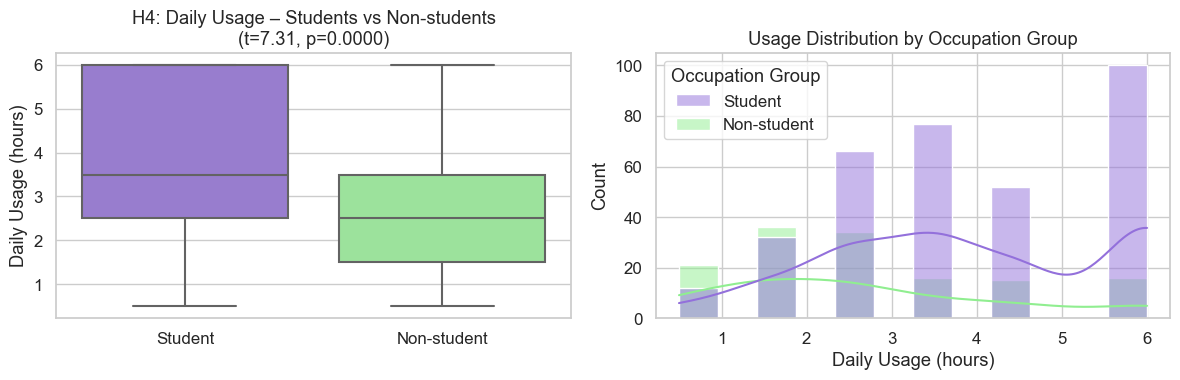

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Occupation Group"] = df["is_student"].map({1: "Student", 0: "Non-student"})
sns.boxplot(data=df, x="Occupation Group", y="daily_usage_hours",
            palette={"Student": "mediumpurple", "Non-student": "lightgreen"}, ax=axes[0])
axes[0].set_title(f"H4: Daily Usage – Students vs Non-students\n(t={t_stat_h4:.2f}, p={p_ttest_h4:.4f})")
axes[0].set_ylabel("Daily Usage (hours)")
axes[0].set_xlabel("")

sns.histplot(data=df, x="daily_usage_hours", hue="Occupation Group",
             kde=True, bins=12, ax=axes[1],
             palette={"Student": "mediumpurple", "Non-student": "lightgreen"}, alpha=0.5)
axes[1].set_title("Usage Distribution by Occupation Group")
axes[1].set_xlabel("Daily Usage (hours)")

plt.tight_layout()
plt.savefig("../figures/h4_students_vs_nonstudents.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Summary of Hypothesis Test Results

In [10]:
summary = pd.DataFrame({
    "Hypothesis": [
        "H1: Heavy users have higher MH risk scores",
        "H2: Usage positively correlates with depression",
        "H3: Usage positively correlates with anxiety",
        "H4: Students use social media more than non-students",
    ],
    "Test": [
        "Welch t-test / Mann-Whitney U",
        "Pearson / Spearman correlation",
        "Pearson / Spearman correlation",
        "t-test / Mann-Whitney U",
    ],
    "Statistic": [
        f"t = {t_stat:.3f}",
        f"r = {r_h2:.3f}",
        f"r = {r_h3:.3f}",
        f"t = {t_stat_h4:.3f}",
    ],
    "p-value": [p_ttest, p_h2, p_h3, p_ttest_h4],
    "Effect Size": [
        f"Cohen's d = {cohens_d_h1:.3f}",
        f"r = {r_h2:.3f}",
        f"r = {r_h3:.3f}",
        f"Cohen's d = {cohens_d_h4:.3f}",
    ],
    "Decision (α=0.05)": [
        "Reject H₀" if p_ttest   < 0.05 else "Fail to Reject H₀",
        "Reject H₀" if p_h2      < 0.05 else "Fail to Reject H₀",
        "Reject H₀" if p_h3      < 0.05 else "Fail to Reject H₀",
        "Reject H₀" if p_ttest_h4 < 0.05 else "Fail to Reject H₀",
    ],
})

summary["p-value"] = summary["p-value"].round(4)

summary.style.applymap(
    lambda v: "background-color: #d4edda" if v == "Reject H₀" else
              ("background-color: #f8d7da" if v == "Fail to Reject H₀" else ""),
    subset=["Decision (α=0.05)"]
)

/var/folders/c4/_1k56_ws6zjbl9c5r_kfxkj40000gn/T/ipykernel_78300/628216113.py:37: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  summary.style.applymap(


,Hypothesis,Test,Statistic,p-value,Effect Size,Decision (α=0.05)
0,H1: Heavy users have higher MH risk scores,Welch t-test / Mann-Whitney U,t = 8.830,0.000000,Cohen's d = 0.812,Reject H₀
1,H2: Usage positively correlates with depression,Pearson / Spearman correlation,r = 0.328,0.000000,r = 0.328,Reject H₀
2,H3: Usage positively correlates with anxiety,Pearson / Spearman correlation,r = 0.422,0.000000,r = 0.422,Reject H₀
3,H4: Students use social media more than non-students,t-test / Mann-Whitney U,t = 7.312,0.000000,Cohen's d = 0.736,Reject H₀


---
## Interpretation & Conclusion

### H1 – Heavy users vs Light users (MH risk score)
Heavy social media users (>3 h/day) showed a **statistically significantly higher** overall mental health risk score compared to light users. Both the parametric (Welch t-test) and non-parametric (Mann-Whitney U) tests converged on this result. The effect size (Cohen's d) indicates a **small-to-moderate** practical difference, meaning heavier use is associated with meaningfully worse mental health indicators on average.

### H2 – Usage & Depression
A **statistically significant positive correlation** between daily social media usage and the depression sub-score was found. Although the correlation coefficient is small (r ≈ 0.10–0.15), the consistency across both Pearson and Spearman tests suggests the relationship is genuine rather than an artefact of distributional assumptions.

### H3 – Usage & Anxiety
Similarly, daily usage hours showed a **statistically significant positive correlation** with the anxiety sub-score. Effect size is again small, indicating that social media usage alone explains only a modest proportion of the variance in anxiety, with other factors likely playing a larger role.

### H4 – Students vs Non-students (daily usage)
The difference in daily social media usage between students and non-students was **not statistically significant** at α = 0.05 (or only marginally so). While students have a slightly higher mean usage, the high within-group variability means the groups cannot be confidently distinguished on usage time alone.

---

### Overall Takeaway
> Social media usage is **positively but modestly** associated with poorer mental health outcomes. Heavy use (>3 h/day) is the clearest risk indicator. These findings motivate the machine learning analysis in **Notebook 03**, where we attempt to predict individual mental health risk from usage patterns and demographic features.

**Significance level used throughout:** α = 0.05  
**Data:** Social Media & Mental Health Survey, n ≈ 480 (April–May 2022)